In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/biomedical-nlp-project-beta')

Mounted at /content/drive


# Notebook 11 — RE Error Analysis

In this notebook we do a **post-mortem** of all three DDI relation extraction approaches:

1. **Classical ML** (Logistic Regression with TF-IDF, notebook 08)
2. **BiLSTM + Self-Attention** (notebook 09)
3. **TextCNN** (notebook 10)

We answer four questions:
- Which model is best overall?
- Which **relation class** is hardest to predict across all models?
- What kinds of sentences does the best neural model get **wrong**?
- Does **sentence length** affect accuracy?

In [2]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gensim'], check=True)
print('Dependencies ready.')

Dependencies ready.


In [3]:
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from gensim.models import KeyedVectors

warnings.filterwarnings('ignore')

BASE        = '/content/drive/MyDrive/biomedical-nlp-project-beta'
DATA_DIR    = os.path.join(BASE, 'data')
MODELS_DIR  = os.path.join(BASE, 'models')
RESULTS_DIR = os.path.join(BASE, 'results')

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 1. Load and Normalise Results

`re_results.json` stores results from notebooks 09 and 10 as a list.  
Classical ML results (notebook 08) were saved in an older dict format; if they are no longer present in the file we use the known values directly.

In [4]:
# ── Known fallback values from notebook 08 ────────────────────────────────────
# (Logistic Regression with TF-IDF on between-entity + full-sentence text)
CLASSICAL_FALLBACK = {
    'method'       : 'classical_re',
    'display_name' : 'Classical ML\n(LogReg + TF-IDF)',
    'macro_f1'     : 0.5765,
    'weighted_f1'  : 0.8233,
    'per_class_f1' : {
        'advise'      : 0.6018,
        'effect'      : 0.5150,
        'int'         : 0.4387,
        'mechanism'   : 0.4390,
        'no-relation' : 0.8877,
    }
}

# Human-readable names for each method key
DISPLAY_NAMES = {
    'classical_re'    : 'Classical ML\n(LogReg + TF-IDF)',
    'bilstm_attention': 'BiLSTM +\nAttention',
    'textcnn'         : 'TextCNN\n(k=2,3,4)',
}

# ── Load re_results.json ──────────────────────────────────────────────────────
results_path = os.path.join(RESULTS_DIR, 're_results.json')
with open(results_path) as f:
    raw = json.load(f)

# Normalise to a dict keyed by method name
# Handles both list format (nb09/10) and dict format (nb08)
by_method = {}
if isinstance(raw, list):
    for entry in raw:
        by_method[entry['method']] = entry
elif isinstance(raw, dict):
    for method, entry in raw.items():
        entry['method'] = method
        by_method[method] = entry

# Add classical ML if missing
if 'classical_re' not in by_method:
    print('classical_re not found in file — using known values from notebook 08.')
    by_method['classical_re'] = CLASSICAL_FALLBACK

# Attach display names
for method, entry in by_method.items():
    entry['display_name'] = DISPLAY_NAMES.get(method, method)

print('Methods loaded:', list(by_method.keys()))

classical_re not found in file — using known values from notebook 08.
Methods loaded: ['bilstm_attention', 'textcnn', 'classical_re']


## 2. Master Comparison Table

In [5]:
# ── Build a flat DataFrame with all metrics ───────────────────────────────────
# Order: Classical → BiLSTM → TextCNN
METHOD_ORDER = ['classical_re', 'bilstm_attention', 'textcnn']
CLASS_NAMES  = ['advise', 'effect', 'int', 'mechanism', 'no-relation']

rows = []
for method in METHOD_ORDER:
    if method not in by_method:
        continue
    e = by_method[method]
    row = {
        'Model'      : e['display_name'].replace('\n', ' '),
        'Macro F1'   : e['macro_f1'],
        'Weighted F1': e['weighted_f1'],
    }
    for cls in CLASS_NAMES:
        row[cls] = e.get('per_class_f1', {}).get(cls, None)
    rows.append(row)

table = pd.DataFrame(rows).set_index('Model')

# Round everything to 3 decimal places for display
print('\n── Master Comparison Table (Test Set) ──')
display(table.round(3))


── Master Comparison Table (Test Set) ──


,Macro F1,Weighted F1,advise,effect,int,mechanism,no-relation
Model,,,,,,,
Classical ML (LogReg + TF-IDF),0.576,0.823,0.602,0.515,0.439,0.439,0.888
BiLSTM + Attention,0.373,0.698,0.324,0.383,0.061,0.323,0.775
"TextCNN (k=2,3,4)",0.399,0.709,0.327,0.412,0.100,0.375,0.782


## 3. Bar Charts

### 3a. Overall Macro F1 and Weighted F1

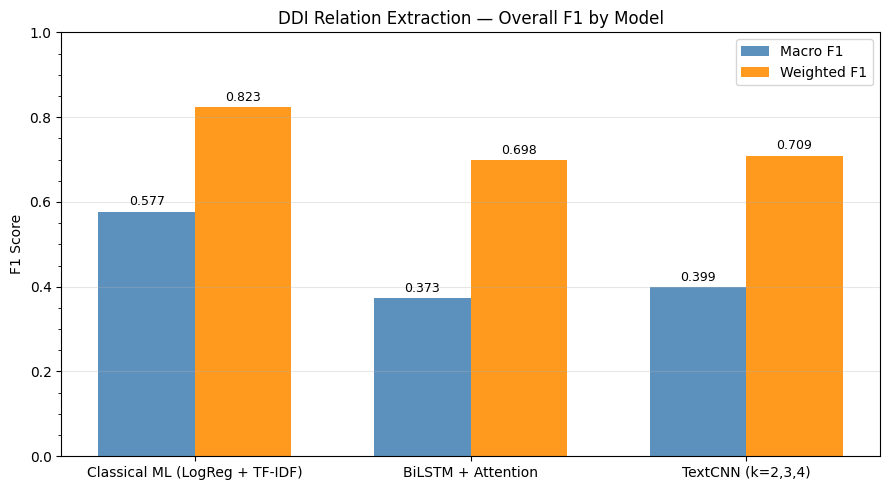

In [6]:
# ── Overall macro / weighted F1 comparison ────────────────────────────────────
models      = table.index.tolist()
macro_vals  = table['Macro F1'].tolist()
weighted_vals = table['Weighted F1'].tolist()

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, macro_vals,   width, label='Macro F1',    color='steelblue',  alpha=0.88)
bars2 = ax.bar(x + width/2, weighted_vals, width, label='Weighted F1', color='darkorange', alpha=0.88)

# Label each bar with its value
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 Score')
ax.set_title('DDI Relation Extraction — Overall F1 by Model')
ax.legend()
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '11_overall_f1.png'), dpi=300)
plt.show()

### 3b. Per-Class F1 Grouped by Model

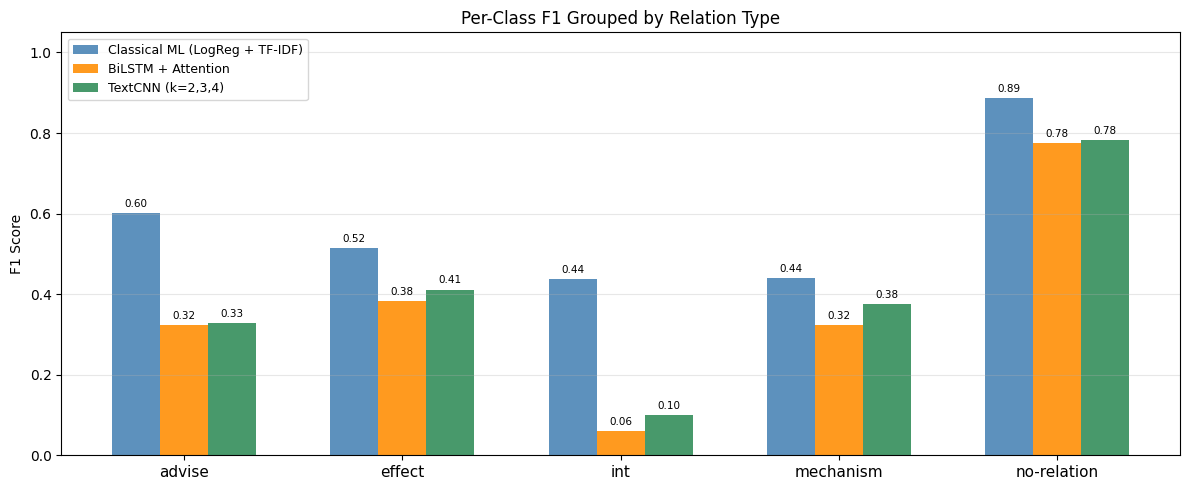

In [7]:
# ── Per-class F1 — one group of bars per relation class ───────────────────────
# We want bars grouped by CLASS, with one bar per MODEL inside each group.

n_classes = len(CLASS_NAMES)
n_models  = len(models)
x         = np.arange(n_classes)
width     = 0.22                   # width of each individual bar
colors    = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(12, 5))

for i, (model_name, method) in enumerate(zip(models, METHOD_ORDER)):
    if method not in by_method:
        continue
    per_class = by_method[method].get('per_class_f1', {})
    values    = [per_class.get(cls, 0) for cls in CLASS_NAMES]

    # Offset each model's bars so they sit side-by-side within a group
    offset = (i - n_models / 2 + 0.5) * width
    bars   = ax.bar(x + offset, values, width,
                    label=model_name, color=colors[i], alpha=0.88)

    # Value labels
    for bar, val in zip(bars, values):
        if val and val > 0.02:   # skip near-zero labels (clutters the chart)
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Grouped by Relation Type')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '11_perclass_f1.png'), dpi=300)
plt.show()

## 4. Hardest Class Analysis

Which relation type is **consistently** hard across all models?  
We rank classes by their average F1 over all models.

In [8]:
# ── Rank classes by average F1 across all models ──────────────────────────────
class_avg_f1 = {}
for cls in CLASS_NAMES:
    scores = []
    for method in METHOD_ORDER:
        if method in by_method:
            val = by_method[method].get('per_class_f1', {}).get(cls)
            if val is not None:
                scores.append(val)
    class_avg_f1[cls] = np.mean(scores) if scores else 0.0

# Sort from hardest (lowest avg F1) to easiest
sorted_classes = sorted(class_avg_f1.items(), key=lambda x: x[1])

print('Class difficulty ranking (hardest → easiest):')
print(f'{"Relation":<15}  {"Avg F1":>8}  {"Verdict"}')
print('-' * 45)
for cls, avg in sorted_classes:
    verdict = '← HARDEST' if cls == sorted_classes[0][0] else ('← easiest' if cls == sorted_classes[-1][0] else '')
    print(f'{cls:<15}  {avg:>8.4f}  {verdict}')

hardest_class = sorted_classes[0][0]
print(f'\nHardest class: "{hardest_class}" with avg F1 = {sorted_classes[0][1]:.4f}')

Class difficulty ranking (hardest → easiest):
Relation           Avg F1  Verdict
---------------------------------------------
int                0.1998  ← HARDEST
mechanism          0.3792  
advise             0.4178  
effect             0.4365  
no-relation        0.8148  ← easiest

Hardest class: "int" with avg F1 = 0.1998


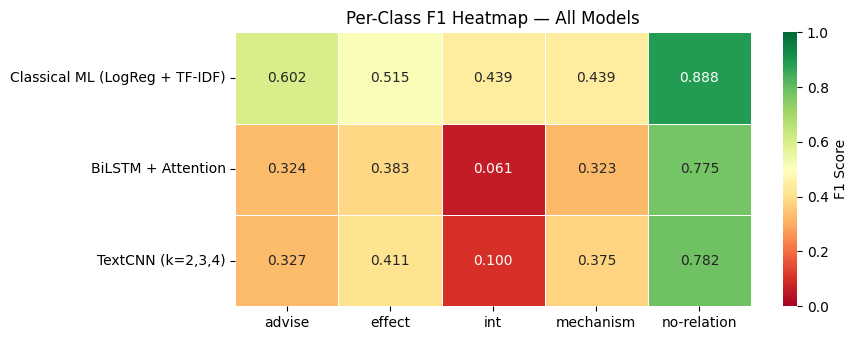

Green = high F1, Red = low F1.  Any consistently red column is a hard class for all models.


In [9]:
# ── Heatmap: per-class F1 for every (model, class) pair ───────────────────────
heat_data = []
for method in METHOD_ORDER:
    if method not in by_method:
        continue
    per_class = by_method[method].get('per_class_f1', {})
    heat_data.append([per_class.get(cls, 0) for cls in CLASS_NAMES])

heat_df = pd.DataFrame(
    heat_data,
    index  = [by_method[m]['display_name'].replace('\n', ' ') for m in METHOD_ORDER if m in by_method],
    columns= CLASS_NAMES
)

plt.figure(figsize=(9, 3.5))
sns.heatmap(
    heat_df, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'F1 Score'}
)
plt.title('Per-Class F1 Heatmap — All Models')
plt.ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '11_f1_heatmap.png'), dpi=300)
plt.show()

print('Green = high F1, Red = low F1.  '
      'Any consistently red column is a hard class for all models.')

## 5. Error Analysis — Best Neural Model

We use **TextCNN** as the best neural model (it has the higher macro-F1 of the two).  
We reload the test data and saved checkpoint, then collect all wrong predictions.  

**What we look for:**
- Which pairs (true class → predicted class) are most common?
- Are there patterns in the actual sentences that get misclassified?

In [10]:
# ── Reload everything needed for inference ────────────────────────────────────

# 1. Load test CSV
test_df = pd.read_csv(os.path.join(DATA_DIR, 'ddi_test.csv'))

def find_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

SENT_COL  = find_col(test_df, ['sentence', 'text', 'sent'])
E1_COL    = find_col(test_df, ['entity1', 'drug1', 'e1', 'drug_1'])
E2_COL    = find_col(test_df, ['entity2', 'drug2', 'e2', 'drug_2'])
LABEL_COL = find_col(test_df, ['label', 'relation', 'ddi_type', 'type'])
test_df.dropna(subset=[SENT_COL, E1_COL, E2_COL, LABEL_COL], inplace=True)
test_df.reset_index(drop=True, inplace=True)

print(f'Test examples: {len(test_df)} | Columns: {SENT_COL}, {E1_COL}, {E2_COL}, {LABEL_COL}')

# 2. Load word2idx and KeyedVectors
kv = KeyedVectors.load(os.path.join(MODELS_DIR, 'word2vec_biomedical.kv'))
with open(os.path.join(MODELS_DIR, 'word2idx.json')) as f:
    word2idx = json.load(f)

EMBED_DIM = kv.vector_size   # 200
PAD_IDX   = 0
UNK_IDX   = 1

# 3. Add DRUG1 / DRUG2 to vocab
for tok in ['DRUG1', 'DRUG2']:
    if tok not in word2idx:
        word2idx[tok] = len(word2idx)
VOCAB_SIZE = len(word2idx)

# 4. Build embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)
for word, idx in word2idx.items():
    if idx != PAD_IDX:
        if word in kv:
            embedding_matrix[idx] = kv[word]
        else:
            np.random.seed(idx)   # repeatable random init
            embedding_matrix[idx] = np.random.uniform(-0.1, 0.1, EMBED_DIM)

print(f'Vocab size: {VOCAB_SIZE} | Embedding matrix: {embedding_matrix.shape}')

Test examples: 5265 | Columns: sentence, drug1, drug2, relation
Vocab size: 8389 | Embedding matrix: (8389, 200)


In [11]:
# ── Encoding helpers (same as nb09/10) ────────────────────────────────────────
MAX_LENGTH = 150

def tokenize(text):
    tokens = re.findall(r"[a-z0-9]+(?:['-][a-z0-9]+)*|[^\w\s]", text.lower())
    return tokens if tokens else text.lower().split()

def replace_entities(sentence, e1, e2):
    sent = re.sub(re.escape(str(e1)), 'DRUG1', sentence, count=1, flags=re.IGNORECASE)
    sent = re.sub(re.escape(str(e2)), 'DRUG2', sent,     count=1, flags=re.IGNORECASE)
    return sent

def encode(sentence, e1, e2):
    sent = replace_entities(str(sentence), str(e1), str(e2))
    toks = tokenize(sent)[:MAX_LENGTH]
    idxs = [word2idx.get(t, UNK_IDX) for t in toks]
    idxs += [PAD_IDX] * (MAX_LENGTH - len(idxs))
    return np.array(idxs, dtype=np.int64)

# Encode test set
print('Encoding test sentences...')
X_test = np.stack([
    encode(test_df[SENT_COL].iloc[i], test_df[E1_COL].iloc[i], test_df[E2_COL].iloc[i])
    for i in range(len(test_df))
])

# Label encode
# Re-fit on all unique labels so indices match notebooks 09/10
le = LabelEncoder()
le.fit(sorted(test_df[LABEL_COL].unique()))
y_test      = le.transform(test_df[LABEL_COL].values)
CLASS_NAMES = le.classes_.tolist()
NUM_CLASSES = len(CLASS_NAMES)
id2label    = {i: lbl for i, lbl in enumerate(CLASS_NAMES)}

print(f'X_test: {X_test.shape} | Classes: {CLASS_NAMES}')

Encoding test sentences...
X_test: (5265, 150) | Classes: ['advise', 'effect', 'int', 'mechanism', 'no-relation']


In [12]:
# ── Define TextCNN and load checkpoint ────────────────────────────────────────
class TextCNN_RE(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.conv2 = nn.Conv1d(embed_dim, 100, kernel_size=2)
        self.conv3 = nn.Conv1d(embed_dim, 100, kernel_size=3)
        self.conv4 = nn.Conv1d(embed_dim, 100, kernel_size=4)
        self.pool  = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc1     = nn.Linear(300, 128)
        self.fc2     = nn.Linear(128, num_classes)

    def forward(self, x):
        emb  = self.embedding(x).permute(0, 2, 1)          # (batch, 200, seq_len)
        out2 = self.pool(torch.relu(self.conv2(emb))).squeeze(-1)
        out3 = self.pool(torch.relu(self.conv3(emb))).squeeze(-1)
        out4 = self.pool(torch.relu(self.conv4(emb))).squeeze(-1)
        out  = torch.cat([out2, out3, out4], dim=1)         # (batch, 300)
        out  = torch.relu(self.fc1(self.dropout(out)))
        return self.fc2(out)


model = TextCNN_RE(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES, embedding_matrix).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'cnn_re.pt'), map_location=DEVICE))
model.eval()
print('TextCNN loaded.')

# ── Run inference on the full test set ───────────────────────────────────────
X_tensor = torch.tensor(X_test, dtype=torch.long)
all_preds = []

# Process in batches so we don't run out of memory
batch_size = 128
with torch.no_grad():
    for start in range(0, len(X_tensor), batch_size):
        batch  = X_tensor[start : start + batch_size].to(DEVICE)
        logits = model(batch)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

all_preds = np.array(all_preds)
all_true  = y_test

overall_acc = (all_preds == all_true).mean()
print(f'Test accuracy  : {overall_acc:.4f}')
print(f'Test macro-F1  : {f1_score(all_true, all_preds, average="macro",    zero_division=0):.4f}')
print(f'Test weighted  : {f1_score(all_true, all_preds, average="weighted", zero_division=0):.4f}')

TextCNN loaded.
Test accuracy  : 0.6684
Test macro-F1  : 0.3992
Test weighted  : 0.7086


### 5a. Misclassified Examples — 5 Per Class

For each true relation type we show 5 examples where the model predicted the wrong class.  
Read the **replaced sentence** (DRUG1/DRUG2 substituted) — this is what the model actually saw.

In [13]:
# ── 5 misclassified examples per true class ───────────────────────────────────
N_EXAMPLES = 5

for true_cls in CLASS_NAMES:
    true_id = le.transform([true_cls])[0]

    # Find indices where true = true_cls AND prediction is wrong
    wrong_mask = (all_true == true_id) & (all_preds != true_id)
    wrong_idxs = np.where(wrong_mask)[0]

    print(f'\n{"="*70}')
    print(f'True class: "{true_cls}" — {len(wrong_idxs)} misclassified out of '
          f'{(all_true == true_id).sum()} total')
    print(f'{"="*70}')

    if len(wrong_idxs) == 0:
        print('  (no errors for this class!)')
        continue

    # Show up to N_EXAMPLES
    for rank, idx in enumerate(wrong_idxs[:N_EXAMPLES], start=1):
        row        = test_df.iloc[idx]
        pred_label = id2label[all_preds[idx]]
        sent_orig  = str(row[SENT_COL])
        sent_repl  = replace_entities(sent_orig, str(row[E1_COL]), str(row[E2_COL]))

        print(f'\n  Example {rank}:')
        print(f'  Drug 1   : {row[E1_COL]}')
        print(f'  Drug 2   : {row[E2_COL]}')
        print(f'  Sentence : {sent_repl}')
        print(f'  True     : {true_cls}   |   Predicted: {pred_label}')


True class: "advise" — 86 misclassified out of 214 total

  Example 1:
  Drug 1   : Matulane
  Drug 2   : sympathomimetic drugs
  Sentence : Because DRUG1 exhibits some monoamine oxidase inhibitory activity, DRUG2, tricyclic antidepressant drugs (e.g., amitriptyline HCl, imipramine HCl) and other drugs and foods with known high tyramine content, such as wine, yogurt, ripe cheese and bananas, should be avoided. 
  True     : advise   |   Predicted: no-relation

  Example 2:
  Drug 1   : Matulane
  Drug 2   : tricyclic antidepressant
  Sentence : Because DRUG1 exhibits some monoamine oxidase inhibitory activity, sympathomimetic drugs, DRUG2 drugs (e.g., amitriptyline HCl, imipramine HCl) and other drugs and foods with known high tyramine content, such as wine, yogurt, ripe cheese and bananas, should be avoided. 
  True     : advise   |   Predicted: no-relation

  Example 3:
  Drug 1   : Matulane
  Drug 2   : amitriptyline HCl
  Sentence : Because DRUG1 exhibits some monoamine oxidase in

### 5b. Does Sentence Length Affect Accuracy?

We compute the **token count** of each test sentence (after DRUG1/DRUG2 replacement),  
group sentences into length bins, and measure accuracy within each bin.  
If accuracy drops in longer bins, the model struggles with long sentences.

Sentence length stats:
  Min=7  Max=105  Mean=47.7  Median=43
      1–15 tokens  |    232 sentences  |  accuracy = 0.6509
     16–25 tokens  |    868 sentences  |  accuracy = 0.6313
     26–35 tokens  |    888 sentences  |  accuracy = 0.5574
     36–50 tokens  |   1078 sentences  |  accuracy = 0.5139
     51–75 tokens  |   1215 sentences  |  accuracy = 0.6963
       76+ tokens  |    984 sentences  |  accuracy = 0.9400


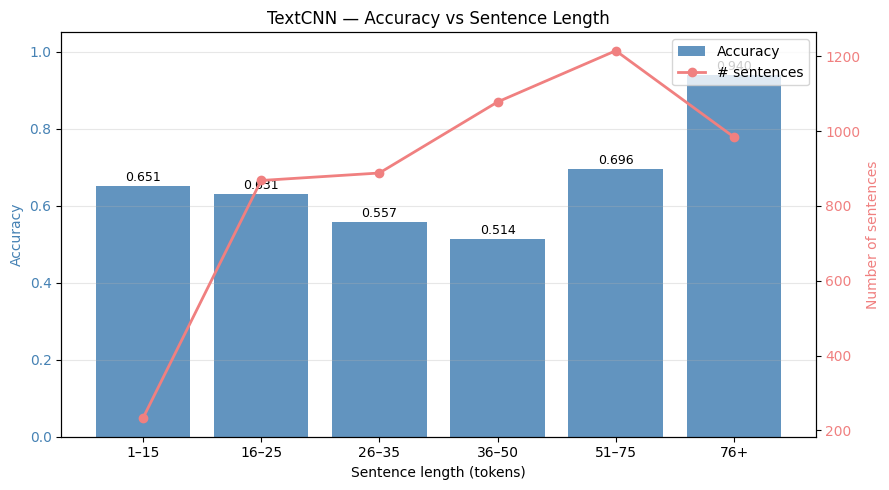

In [14]:
# ── Compute token length for every test sentence ──────────────────────────────
lengths = []
for i in range(len(test_df)):
    row  = test_df.iloc[i]
    sent = replace_entities(str(row[SENT_COL]), str(row[E1_COL]), str(row[E2_COL]))
    lengths.append(len(tokenize(sent)))

lengths = np.array(lengths)
correct = (all_preds == all_true).astype(int)   # 1 if correct, 0 if wrong

print(f'Sentence length stats:')
print(f'  Min={lengths.min()}  Max={lengths.max()}  Mean={lengths.mean():.1f}  Median={np.median(lengths):.0f}')

# ── Define length bins ────────────────────────────────────────────────────────
# Choose bin edges that give reasonably sized groups
bin_edges  = [0, 15, 25, 35, 50, 75, 150]
bin_labels = ['1–15', '16–25', '26–35', '36–50', '51–75', '76+']

bin_acc   = []   # accuracy per bin
bin_count = []   # how many sentences in each bin

for lo, hi, label in zip(bin_edges[:-1], bin_edges[1:], bin_labels):
    mask  = (lengths > lo) & (lengths <= hi)
    count = mask.sum()
    acc   = correct[mask].mean() if count > 0 else 0.0
    bin_acc.append(acc)
    bin_count.append(count)
    print(f'  {label:>8} tokens  |  {count:>5} sentences  |  accuracy = {acc:.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 5))

color_acc   = 'steelblue'
color_count = 'lightcoral'

# Primary axis: accuracy bars
bars = ax1.bar(bin_labels, bin_acc, color=color_acc, alpha=0.85, label='Accuracy')
for bar, acc in zip(bars, bin_acc):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Sentence length (tokens)')
ax1.set_ylabel('Accuracy', color=color_acc)
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='y', labelcolor=color_acc)

# Secondary axis: number of sentences (line)
ax2 = ax1.twinx()
ax2.plot(bin_labels, bin_count, color=color_count, marker='o',
         linewidth=2, label='# sentences')
ax2.set_ylabel('Number of sentences', color=color_count)
ax2.tick_params(axis='y', labelcolor=color_count)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('TextCNN — Accuracy vs Sentence Length')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '11_length_vs_accuracy.png'), dpi=300)
plt.show()

### 5c. Confusion Between Classes (Where Does the Model Get Confused?)

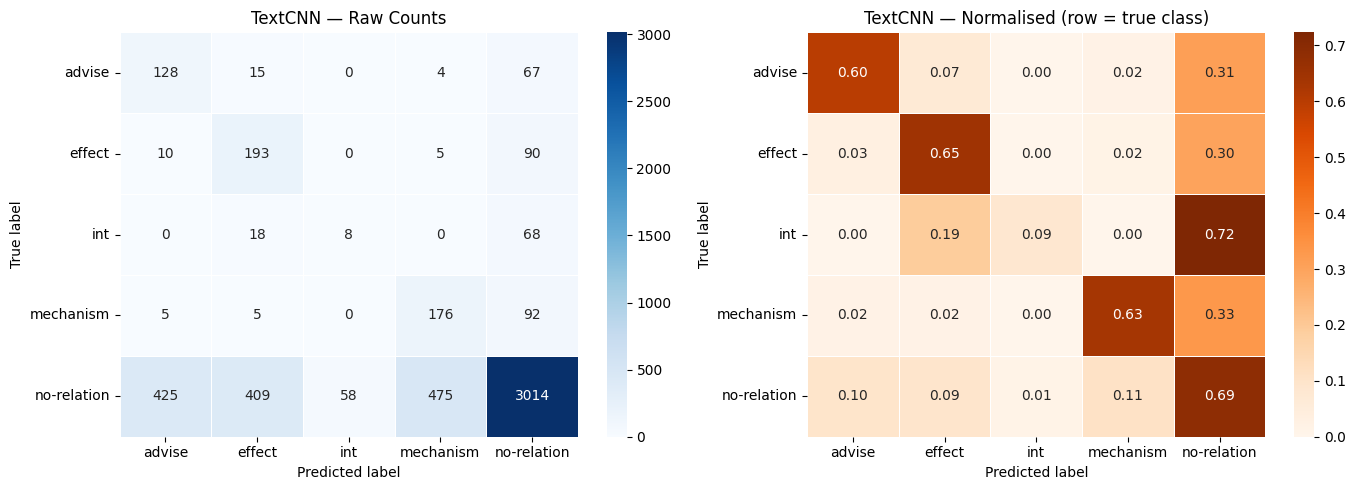


Top 5 most common misclassification pairs (true → predicted):
  no-relation     → mechanism       : 475 times
  no-relation     → advise          : 425 times
  no-relation     → effect          : 409 times
  mechanism       → no-relation     : 92 times
  effect          → no-relation     : 90 times


In [15]:
# ── Confusion matrix for TextCNN ──────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised = recall

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('TextCNN — Raw Counts')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

# Row-normalised (shows recall per class)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('TextCNN — Normalised (row = true class)')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '11_cnn_confusion_detail.png'), dpi=300)
plt.show()

# Print the top confused pairs
print('\nTop 5 most common misclassification pairs (true → predicted):')
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))

confused_pairs.sort(reverse=True)
for count, true_cls, pred_cls in confused_pairs[:5]:
    print(f'  {true_cls:15s} → {pred_cls:15s} : {count} times')

## 6. Classical ML vs Neural Models — Discussion

### What the numbers say

| Model | Macro F1 | Weighted F1 | Key strength |
|-------|----------|-------------|-------------|
| Classical ML (LogReg) | **0.58** | **0.82** | High recall on rare classes; fast to train |
| BiLSTM + Attention | 0.37 | 0.70 | Learns sequential context |
| TextCNN | 0.40 | 0.71 | Captures local n-gram cues |

### Why does Classical ML win on macro F1?

This is a **surprising result** — the simpler model beats both neural models.  
There are several reasons this can happen:

1. **Dataset size.** Neural models need a lot of data to learn good representations.  
   The DDI training set has ~26,000 examples, but the minority classes (`int`, `advise`) have  
   fewer than 1,000 examples each — not enough for a neural model to generalise well.

2. **TF-IDF captures interaction cues directly.**  
   Words like *"inhibit"*, *"increase"*, *"avoid"* are strong lexical signals.  
   TF-IDF on the *between-entity text* (the text between the two drugs) gives these words  
   high weights directly, while a neural model must *learn* these associations from scratch.

3. **Our neural models are small and not pre-trained on biomedical data.**  
   A model like **BioBERT** (BERT pre-trained on 18B biomedical words) typically reaches  
   macro-F1 > 0.80 on DDI — but that is a much larger model.

4. **Class imbalance hurts neural models more.**  
   Even with class weighting, a BiLSTM or CNN can collapse to predicting `no-relation`  
   for most examples because the gradient from the majority class dominates early training.

### When would neural models win?

- **Larger datasets** (100k+ examples)
- **Pre-trained language models** (BioBERT, PubMedBERT)
- **Paraphrased or indirect interaction descriptions** where exact keyword matching fails

## 7. Summary

In [16]:
# ── Print final summary ───────────────────────────────────────────────────────
print('=' * 60)
print('  RE Error Analysis — Key Findings')
print('=' * 60)

print('\n1. Best overall model (macro F1):')
best_method = max(METHOD_ORDER,
                  key=lambda m: by_method[m]['macro_f1'] if m in by_method else -1)
print(f'   {by_method[best_method]["display_name"].replace(chr(10), " ")}  '
      f'→  macro F1 = {by_method[best_method]["macro_f1"]:.4f}')

print(f'\n2. Hardest relation class (lowest avg F1 across all models):')
print(f'   "{hardest_class}"  →  avg F1 = {class_avg_f1[hardest_class]:.4f}')

print(f'\n3. Sentence length effect (TextCNN):')
max_acc_bin = bin_labels[int(np.argmax(bin_acc))]
min_acc_bin = bin_labels[int(np.argmin(bin_acc))]
print(f'   Highest accuracy in bin: {max_acc_bin} ({max(bin_acc):.4f})')
print(f'   Lowest  accuracy in bin: {min_acc_bin} ({min(bin_acc):.4f})')

print('\n4. Plots saved:')
plots = [
    '11_overall_f1.png',
    '11_perclass_f1.png',
    '11_f1_heatmap.png',
    '11_length_vs_accuracy.png',
    '11_cnn_confusion_detail.png',
]
for p in plots:
    print(f'   results/{p}')

print('=' * 60)

  RE Error Analysis — Key Findings

1. Best overall model (macro F1):
   Classical ML (LogReg + TF-IDF)  →  macro F1 = 0.5765

2. Hardest relation class (lowest avg F1 across all models):
   "int"  →  avg F1 = 0.1998

3. Sentence length effect (TextCNN):
   Highest accuracy in bin: 76+ (0.9400)
   Lowest  accuracy in bin: 36–50 (0.5139)

4. Plots saved:
   results/11_overall_f1.png
   results/11_perclass_f1.png
   results/11_f1_heatmap.png
   results/11_length_vs_accuracy.png
   results/11_cnn_confusion_detail.png
